In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gti-upm/leapgestrecog")

print("Path to dataset files:", path)
url ="https://www.kaggle.com/datasets/gti-upm/leapgestrecog"

100%|██████████| 2.13G/2.13G [00:24<00:00, 95.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1


In [2]:
!ls /root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1/leapgestrecog/leapGestRecog

00  01	02  03	04  05	06  07	08  09


In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms,datasets
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

In [23]:
IMG_SIZE =64
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [34]:
from torchvision import datasets
from torch.utils.data import ConcatDataset, random_split, DataLoader

datasets_list = []

for i in range(10):
    ds = datasets.ImageFolder(
        root=f"/root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1/leapgestrecog/leapGestRecog/0{i}",
        transform=transform
    )
    datasets_list.append(ds)


full_dataset = ConcatDataset(datasets_list)

In [35]:
train =int(0.8 * len(full_dataset))
test = len(full_dataset) - train
from torch.utils.data import random_split

train_dataset,test_dataset = random_split(full_dataset ,[train,test])

In [36]:
train_loader = DataLoader(train_dataset, batch_size =32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size =32, shuffle=False)

In [37]:
import numpy as np
def imshow(image, label):
    image = image / 2 + 0.5
    npimage = image.numpy()

    if npimage.ndim == 3:
        if npimage.shape[0] == 3:
            npimage = np.transpose(npimage, (1, 2, 0))
        else:

            npimage = np.squeeze(npimage)

    plt.imshow(npimage, cmap='winter' if npimage.ndim == 2 else None)
    plt.title(f"Label: {label}")
    plt.show()

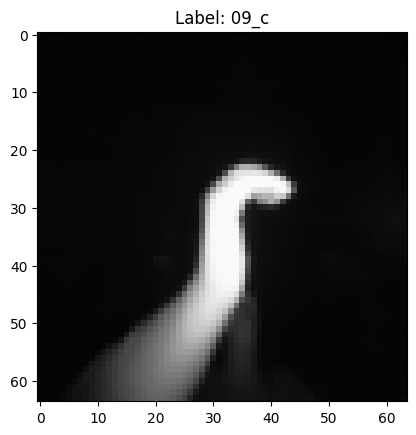

In [52]:
dataiter =iter(train_loader)
images , label = next(dataiter)
class_names = datasets_list[0].classes
imshow(images[0], class_names[label[0]])

In [54]:
images[0].shape

torch.Size([3, 64, 64])

In [39]:
class CustomModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 =nn.Linear(16384, 128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x,1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [40]:
model = CustomModel()
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [42]:
model.to(device)

CustomModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [43]:
device

'cuda'

In [48]:
epochs = 1
model.train()
for epoch in tqdm(range(epochs)):
    total_loss = 0
    for image, label in train_loader:
        # placing into device
        image,label = image.to(device),label.to(device)
        #forward
        outputs = model(image)
        #loss
        loss = criterion(outputs,label)
        #stop the optimizer
        optimizer.zero_grad()
        #backpropagartion
        loss.backward()
        #step
        optimizer.step()

        total_loss += loss.item()
    print(f"epochs : {epoch}/{epochs} ===>>> Loss : {total_loss/len(train_loader)}")

100%|██████████| 1/1 [01:00<00:00, 60.36s/it]

epochs : 0/1 ===>>> Loss : 0.06127235091771581


In [49]:
model.eval()
with torch.inference_mode():
    test_loss =0
    correct =0
    total = 0
    for t_images, t_label in test_loader:

        t_images,t_label =t_images.to(device),t_label.to(device)

        t_outputs = model(t_images)

        t_loss = criterion(t_outputs,t_label)

        _,y_pred = torch.max(t_outputs,1)
        # print(y_pred)
        # print(t_label)
        total+=t_label.size(0)
        correct += (y_pred ==t_label).sum().item()

    avg_loss = total_loss / len(test_loader)
    accuracy = (correct / total) *100

    print(f"Eval Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.2f}%")


Eval Loss: 0.2451
Accuracy: 97.67%


In [51]:
torch.save(model.state_dict(),"hand_model_1.pt")